In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df_pca     = pd.read_csv(r"C:\Users\ADMIN\Desktop\12409771_INT375\PCA0000_2011_MDDS.csv")
df_age1    = pd.read_csv(r"C:\Users\ADMIN\Desktop\12409771_INT375\DDWC-000013.csv")
df_age2    = pd.read_csv(r"C:\Users\ADMIN\Desktop\12409771_INT375\DDW-0000C-13.csv")
df_religion= pd.read_csv(r"C:\Users\ADMIN\Desktop\12409771_INT375\popby_religion_0.csv")
df_rhs     = pd.read_csv(r"C:\Users\ADMIN\Desktop\12409771_INT375\RHS_2015_ch-1_table_1.csv")

print("PCA shape     :", df_pca.shape)
print("Age1 shape    :", df_age1.shape)
print("Age2 shape    :", df_age2.shape)
print("Religion shape:", df_religion.shape)
print("RHS shape     :", df_rhs.shape)

import subprocess, sys
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import panel as pn
pn.extension('plotly', design='material', sizing_mode='stretch_width')
print('🎉 All good!')

PCA shape     : (108, 98)
Age1 shape    : (3708, 15)
Age2 shape    : (3708, 14)
Religion shape: (9, 5)
RHS shape     : (37, 8)


🎉 All good!


In [4]:
df_states = df_pca[
    (df_pca['Level'] == 'STATE') &
    (df_pca['TRU'] == 'Total')
].copy().reset_index(drop=True)

df_states['Literacy Rate'] = (
    df_states['Literates Population Person'] /
    df_states['Total Population Person'] * 100
).round(2)

df_states['Male Literacy Rate'] = (
    df_states['Literates Population Male'] /
    df_states['Total Population Male'] * 100
).round(2)

df_states['Female Literacy Rate'] = (
    df_states['Literates Population Female'] /
    df_states['Total Population Female'] * 100
).round(2)

df_states['Gender Literacy Gap'] = (
    df_states['Male Literacy Rate'] - df_states['Female Literacy Rate']
).round(2)

df_states['SC %'] = (
    df_states['Scheduled Castes population Person'] /
    df_states['Total Population Person'] * 100
).round(2)

df_states['ST %'] = (
    df_states['Scheduled Tribes population Person'] /
    df_states['Total Population Person'] * 100
).round(2)

df_states['Worker %'] = (
    df_states['Total Worker Population Person'] /
    df_states['Total Population Person'] * 100
).round(2)

df_age = df_age1[df_age1['Area Name'].str.strip() == 'INDIA'].copy()
df_age = df_age[df_age['Age'] != 'All ages'].copy()
df_age['Age'] = pd.to_numeric(df_age['Age'], errors='coerce')
df_age = df_age.dropna(subset=['Age']).sort_values('Age')

bins   = list(range(0, 86, 5)) + [200]
labels = [f'{i}-{i+4}' for i in range(0, 85, 5)] + ['85+']
df_age['Age Group'] = pd.cut(df_age['Age'], bins=bins, labels=labels[:len(bins)-1], right=False)
df_pyramid = df_age.groupby('Age Group', observed=True).agg(
    Males   = ('Total - Males',   'sum'),
    Females = ('Total - Females', 'sum')
).reset_index()
df_pyramid['Males_M']   = df_pyramid['Males']   / 1e6
df_pyramid['Females_M'] = df_pyramid['Females'] / 1e6

df_rel = df_religion[df_religion['Religion'] != 'Total Population'].copy()

df_rhs['Number of Districts'] = pd.to_numeric(df_rhs['Number of Districts'], errors='coerce')
df_rhs['Number of Villages']  = pd.to_numeric(df_rhs['Number of Villages'],  errors='coerce')
df_rhs['Area [Sq. Km.] - Total'] = pd.to_numeric(df_rhs['Area [Sq. Km.] - Total'], errors='coerce')
df_rhs['Villages per District'] = (
    df_rhs['Number of Villages'] / df_rhs['Number of Districts']
).round(0)
df_rhs = df_rhs[df_rhs['State/UT'] != 'Total'].dropna(subset=['State/UT']).copy()

print("States in PCA :", len(df_states))
print("Age rows      :", len(df_age))
print("Pyramid rows  :", len(df_pyramid))
print("Religions     :", len(df_rel))
print("RHS states    :", len(df_rhs))

States in PCA : 35
Age rows      : 100
Pyramid rows  : 18
Religions     : 8
RHS states    : 37


In [5]:
df_rural = df_pca[(df_pca['Level'] == 'STATE') & (df_pca['TRU'] == 'Rural')].copy()
df_urban = df_pca[(df_pca['Level'] == 'STATE') & (df_pca['TRU'] == 'Urban')].copy()

df_pop = df_states[['Name', 'Total Population Person']].copy()

df_pop = df_pop.merge(
    df_rural[['Name', 'Total Population Person']].rename(
        columns={'Total Population Person': 'Rural Population'}),
    on='Name', how='left'
)
df_pop = df_pop.merge(
    df_urban[['Name', 'Total Population Person']].rename(
        columns={'Total Population Person': 'Urban Population'}),
    on='Name', how='left'
)
df_pop = df_pop.sort_values('Total Population Person', ascending=False)


In [6]:
sort_widget = pn.widgets.Select(
    name='Sort By',
    options=['Total Population Person', 'Rural Population', 'Urban Population'],
    value='Total Population Person',
    width=250
)
topn_widget = pn.widgets.IntSlider(
    name='Top N States', start=5, end=35, step=5, value=15, width=250
)

df_rural = df_pca[(df_pca['Level'] == 'STATE') & (df_pca['TRU'] == 'Rural')]
df_urban = df_pca[(df_pca['Level'] == 'STATE') & (df_pca['TRU'] == 'Urban')]

df_pop = df_states[['Name', 'Total Population Person']].copy()

df_pop = df_pop.merge(
    df_rural[['Name', 'Total Population Person']]
    .rename(columns={'Total Population Person': 'Rural Population'}),
    on='Name', how='left'
)

df_pop = df_pop.merge(
    df_urban[['Name', 'Total Population Person']]
    .rename(columns={'Total Population Person': 'Urban Population'}),
    on='Name', how='left'
)
df = df_pop.sort_values('Total Population Person', ascending=False).head(15)
fig1 = px.bar(
    df,
    x='Name',
    y=['Rural Population', 'Urban Population'],
    title='Population by State (Rural vs Urban)'
)
fig1.update_layout(
    barmode='stack',
    xaxis_tickangle=-40,
    height=500
)
chart1 = pn.Column(
    fig1
)

chart1

Column(design=<class 'panel.theme.materi..., sizing_mode='stretch_width')
    [0] Plotly(Figure, design=<class 'panel.theme.materi..., sizing_mode='stretch_width')

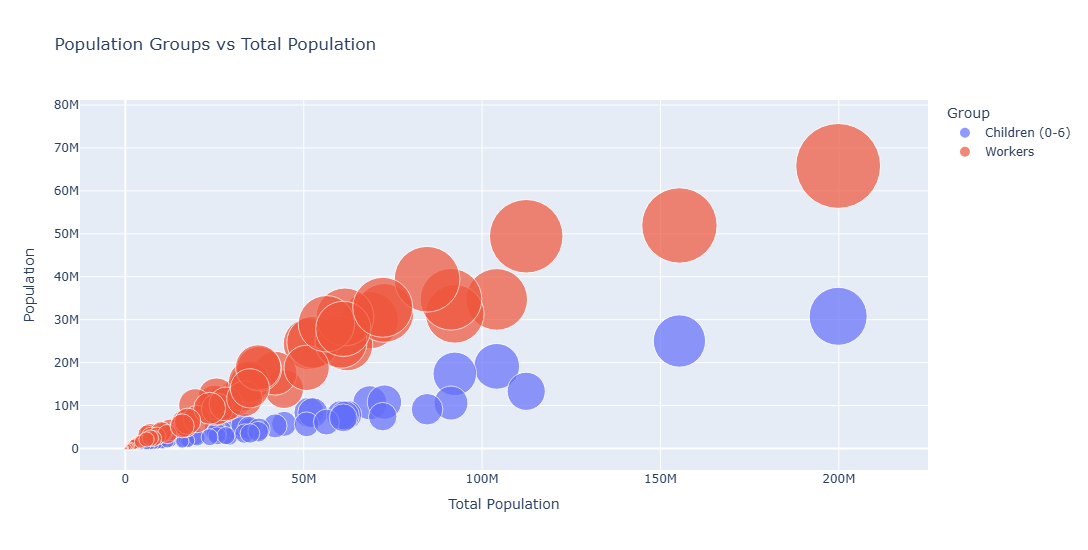

In [7]:
df = df_pca[df_pca['Level'] == 'STATE']
df_plot = pd.DataFrame({
    'State': df['Name'],
    'Total Population': df['Total Population Person'],
    'Children (0-6)': df['Population in the age group 0-6 Person'],
    'Workers': df['Total Worker Population Person']
})
df_melt = df_plot.melt(
    id_vars=['State', 'Total Population'],
    value_vars=['Children (0-6)', 'Workers'],
    var_name='Group',
    value_name='Population'
)
fig = px.scatter(
    df_melt,
    x='Total Population',
    y='Population',
    color='Group',
    size='Population',
    hover_name='State',
    title='Population Groups vs Total Population',
    size_max=60
)
fig.update_layout(height=550)
color_discrete_map={
    'Children (0-6)': '#42A5F5',
    'Workers': '#EF5350'
}
chart2=fig
chart2

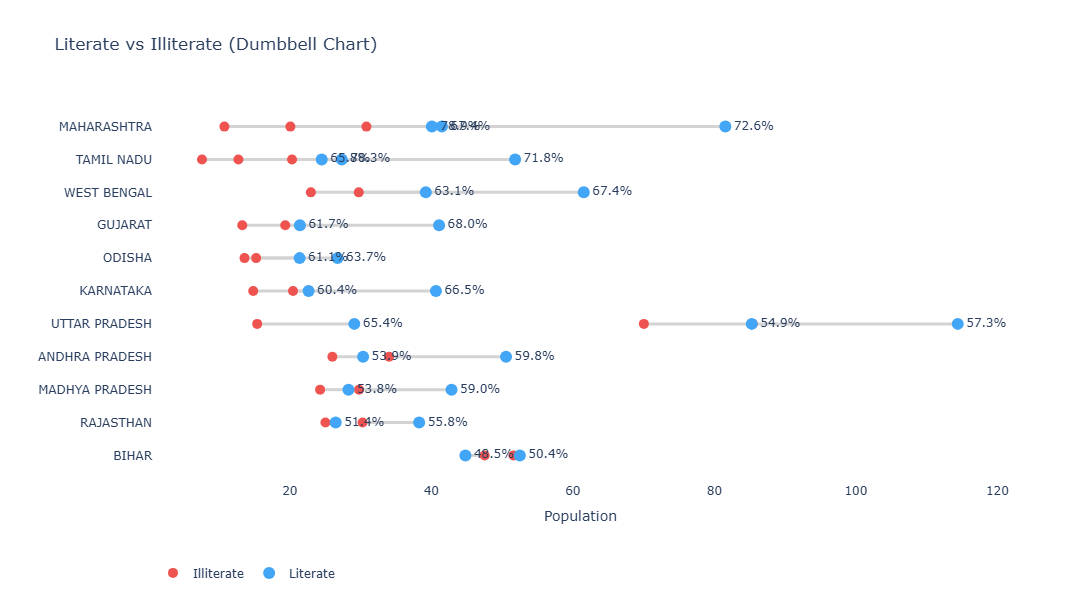

In [8]:
df = df_pca[df_pca['Level'] == 'STATE'].copy()
df = df.sort_values('Total Population Person', ascending=False).head(25)
df['Literacy %'] = (
    df['Literates Population Person'] /
    (df['Literates Population Person'] + df['Illiterate Persons'])
) * 100
df = df.sort_values('Literacy %')
df['Literates Population Person'] /= 1e6
df['Illiterate Persons'] /= 1e6
import plotly.graph_objects as go

fig = go.Figure()
for i, state in enumerate(df['Name']):
    fig.add_trace(go.Scatter(
        x=[
            df['Illiterate Persons'].iloc[i],
            df['Literates Population Person'].iloc[i]
        ],
        y=[state, state],
        mode='lines',
        line=dict(color='lightgray', width=3),
        showlegend=False
    ))
fig.add_trace(go.Scatter(
    x=df['Illiterate Persons'],
    y=df['Name'],
    mode='markers',
    name='Illiterate',
    marker=dict(color='#EF5350', size=10)
))
fig.add_trace(go.Scatter(
    x=df['Literates Population Person'],
    y=df['Name'],
    mode='markers+text',
    name='Literate',
    marker=dict(color='#42A5F5', size=12),
    text=df['Literacy %'].round(1).astype(str) + '%',
    textposition='middle right'
))
fig.update_layout(
    title='Literate vs Illiterate (Dumbbell Chart)',
    height=600,
    xaxis_title='Population',
    yaxis_title='',
    plot_bgcolor='white',
    legend=dict(orientation='h', y=-0.2)
)

chart3=fig
chart3

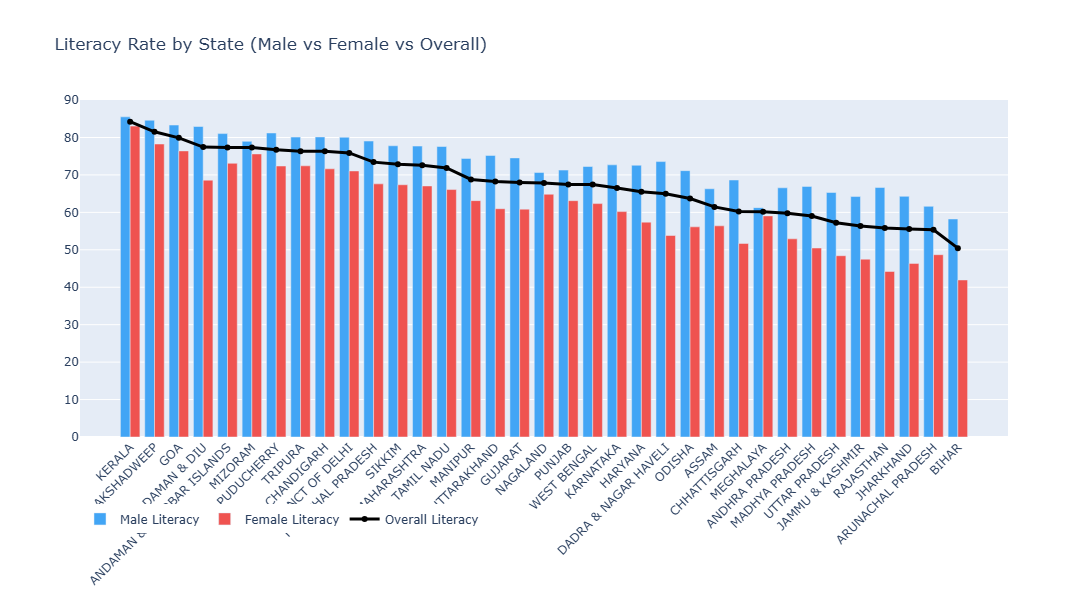

In [9]:
df = df_states.copy()
df = df.sort_values('Literacy Rate', ascending=False)
import plotly.graph_objects as go
fig = go.Figure()
fig.add_bar(
    x=df['Name'],
    y=df['Male Literacy Rate'],
    name='Male Literacy',
    marker_color='#42A5F5'
)
fig.add_bar(
    x=df['Name'],
    y=df['Female Literacy Rate'],
    name='Female Literacy',
    marker_color='#EF5350'
)
fig.add_scatter(
    x=df['Name'],
    y=df['Literacy Rate'],
    mode='lines+markers',
    name='Overall Literacy',
    line=dict(color='black', width=3),
    marker=dict(size=6)
)
fig.update_layout(
    barmode='group',
    title='Literacy Rate by State (Male vs Female vs Overall)',
    xaxis_tickangle=-45,
    height=600,
    legend=dict(orientation='h', y=-0.2)
)
chart4=fig
chart4

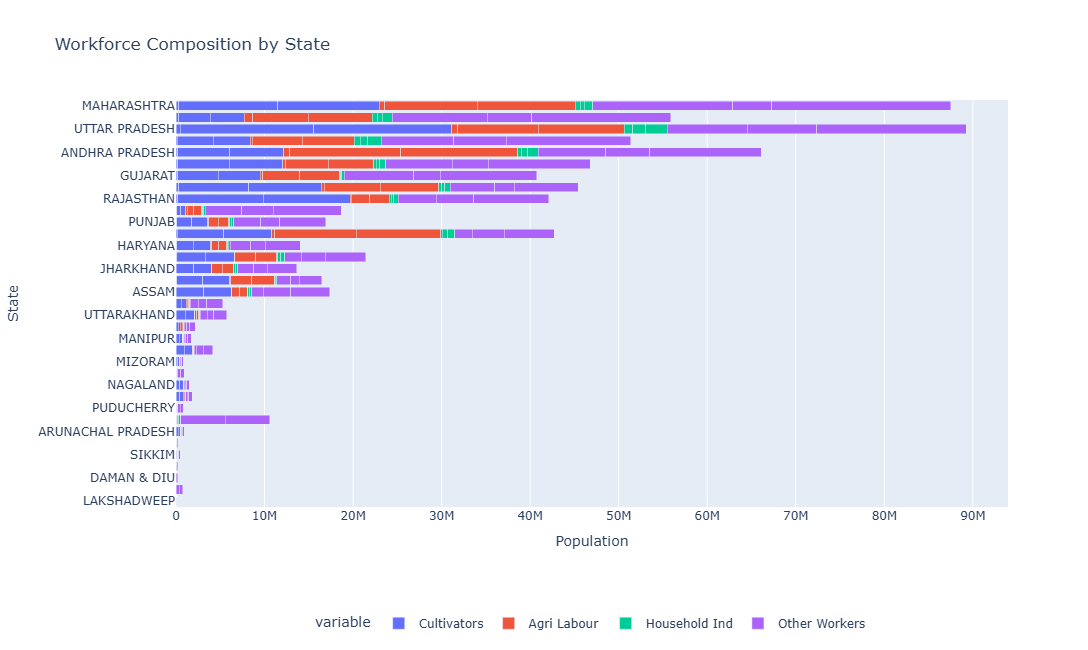

In [10]:
df = df_pca.copy()
df = df[df['Level'] == 'STATE']
df = df.rename(columns={
    'Main Cultivator Population Person': 'Cultivators',
    'Main Agricultural Labourers Population Person': 'Agri Labour',
    'Main Household Industries Population Person': 'Household Ind',
    'Main Other Workers Population Person': 'Other Workers'
})
df = df.sort_values('Total Worker Population Person', ascending=True)
fig = px.bar(
    df,
    y='Name',
    x=['Cultivators','Agri Labour','Household Ind','Other Workers'],
    title='Workforce Composition by State',
    labels={'value': 'Population', 'Name': 'State'},
)

fig.update_layout(
    barmode='stack',
    height=650,
    legend=dict(
        orientation='h',
        y=-0.25,
        x=0.5,
        xanchor='center'
    )
)
chart5=fig
chart5

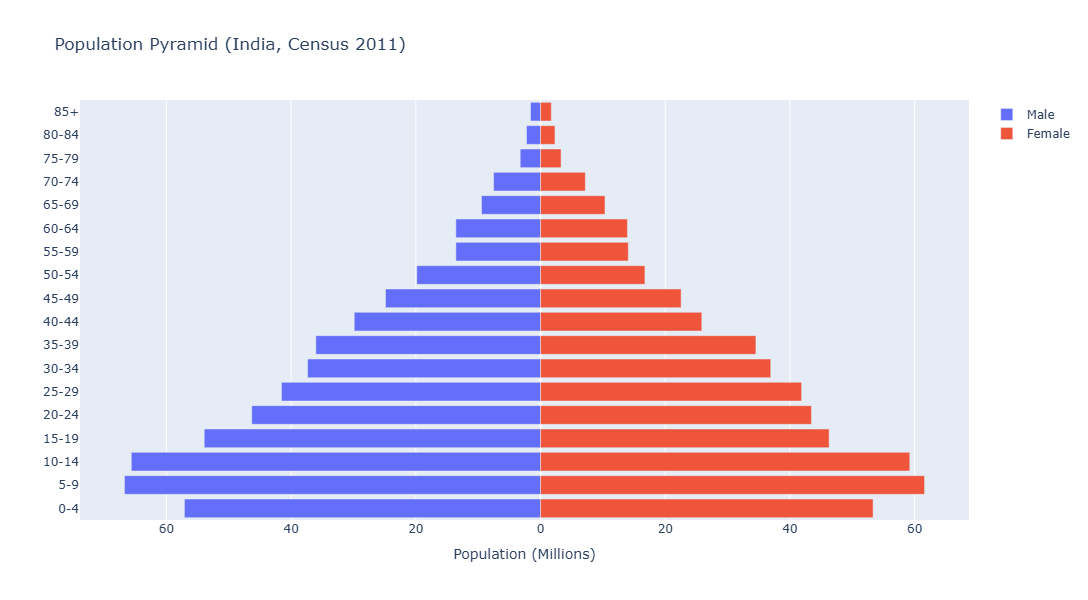

In [11]:
df = df_pyramid.copy()
fig = go.Figure()
fig.add_bar(
    y=df['Age Group'],
    x=-df['Males_M'],
    name='Male',
    orientation='h'
)
fig.add_bar(
    y=df['Age Group'],
    x=df['Females_M'],
    name='Female',
    orientation='h'
)
fig.update_layout(
    title='Population Pyramid (India, Census 2011)',
    barmode='relative',
    height=600,
    xaxis_title='Population (Millions)'
)
fig.update_xaxes(
    tickvals=[-60, -40, -20, 0, 20, 40, 60],
    ticktext=['60', '40', '20', '0', '20', '40', '60']
)
chart6 = fig
chart6

In [12]:
df = df_rel.copy()
color_map = {
    'Hindus'              : '#FF6F00',
    'Muslims'             : '#1565C0',
    'Christians'          : '#2E7D32',
    'Sikhs'               : '#F57F17',
    'Buddhists'           : '#6A1B9A',
    'Jains'               : '#880E4F',
    'Other Religions'     : '#37474F',
    'Religion not stated' : '#9E9E9E'
}
fig1 = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=['Tamil Nadu', 'All India']
)
fig1.add_trace(
    go.Pie(
        labels=df['Religion'],
        values=df['Percentage Tamil Nadu'],
        hole=0.4,   # 👈 makes donut
        marker=dict(colors=[color_map.get(r, '#999') for r in df['Religion']])
    ),
    row=1, col=1
)
fig1.add_trace(
    go.Pie(
        labels=df['Religion'],
        values=df['Percentage All India'],
        hole=0.4,   # 👈 makes donut
        marker=dict(colors=[color_map.get(r, '#999') for r in df['Religion']])
    ),
    row=1, col=2
)
fig1.update_layout(
    title='Religion Distribution: Tamil Nadu vs All India',
    height=450
)
fig2 = px.bar( df.sort_values('Percentage All India'), x='Percentage All India', y='Religion', orientation='h', color='Religion', color_discrete_map=color_map, title='Religion Distribution — All India' )
fig2.update_layout(height=450)
chart7 = pn.Column(
    fig1,
    fig2
)
chart7

Column(design=<class 'panel.theme.materi..., sizing_mode='stretch_width')
    [0] Plotly(Figure, design=<class 'panel.theme.materi..., sizing_mode='stretch_width')
    [1] Plotly(Figure, design=<class 'panel.theme.materi..., sizing_mode='stretch_width')

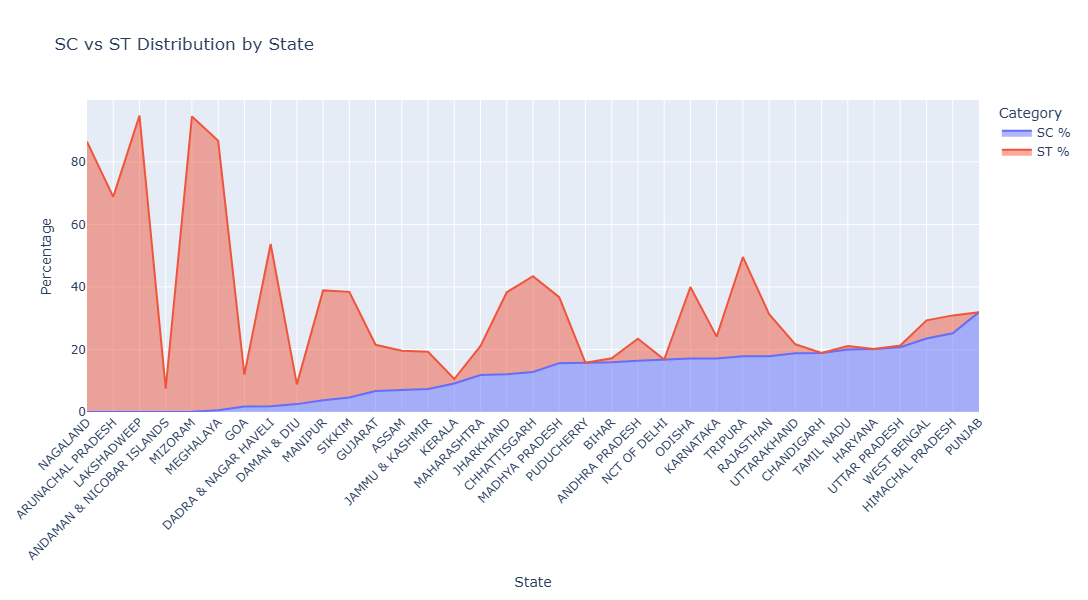

In [13]:
df = df_states.copy()
df = df.sort_values('SC %')
df_long = df.melt(
    id_vars='Name',
    value_vars=['SC %', 'ST %'],
    var_name='Category',
    value_name='Percentage'
)
fig = px.area(
    df_long,
    x='Name',
    y='Percentage',
    color='Category',
    title='SC vs ST Distribution by State'
)
fig.update_layout(
    height=600,
    xaxis_tickangle=-45,
    xaxis_title='State',
    yaxis_title='Percentage'
)
chart8 = fig
chart8

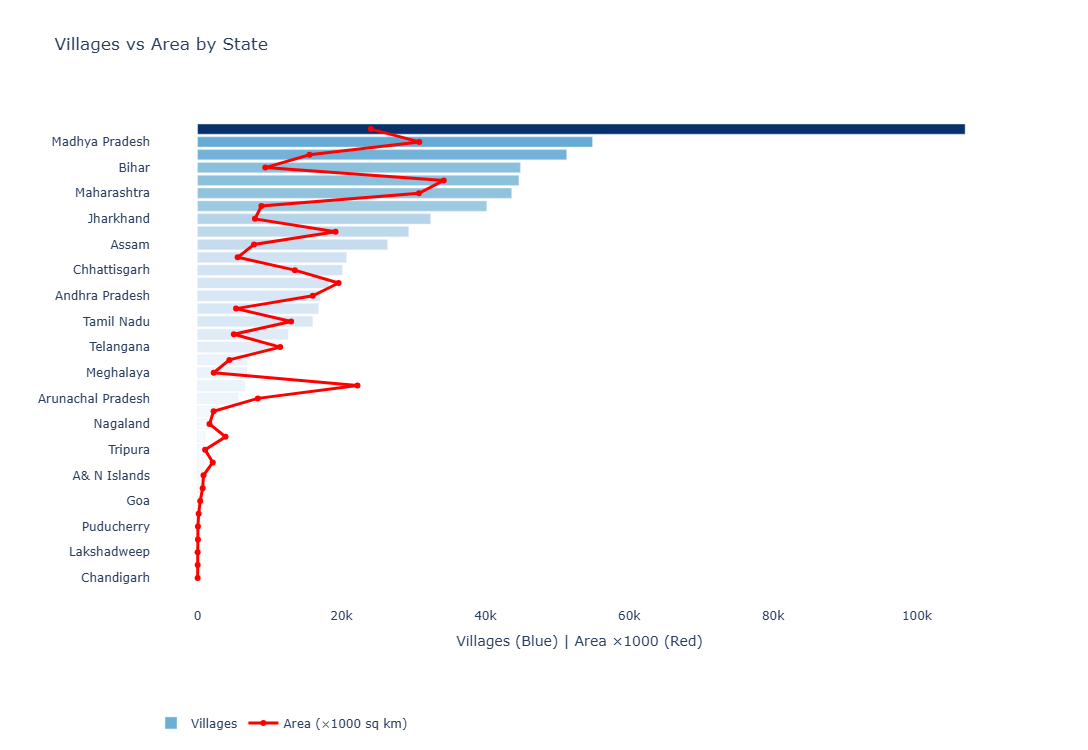

In [14]:
df = df_rhs.copy()
df = df[df['State/UT'] != 'All India']
df = df.sort_values('Number of Villages')
df['Area_scaled'] = df['Area [Sq. Km.] - Total'] / 10
fig = go.Figure()
fig.add_bar(
    x=df['Number of Villages'],
    y=df['State/UT'],
    orientation='h',
    name='Villages',
    marker=dict(
        color=df['Number of Villages'],
        colorscale='Blues'
    )
)
fig.add_scatter(
    x=df['Area_scaled'],
    y=df['State/UT'],
    mode='lines+markers',
    name='Area (×1000 sq km)',
    line=dict(color='red', width=3)
)
fig.update_layout(
    title='Villages vs Area by State',
    height=750,
    xaxis_title='Villages (Blue) | Area ×1000 (Red)',
    yaxis_title='',
    legend=dict(orientation='h', y=-0.2),
    plot_bgcolor='white'
)

chart9 = fig
chart9

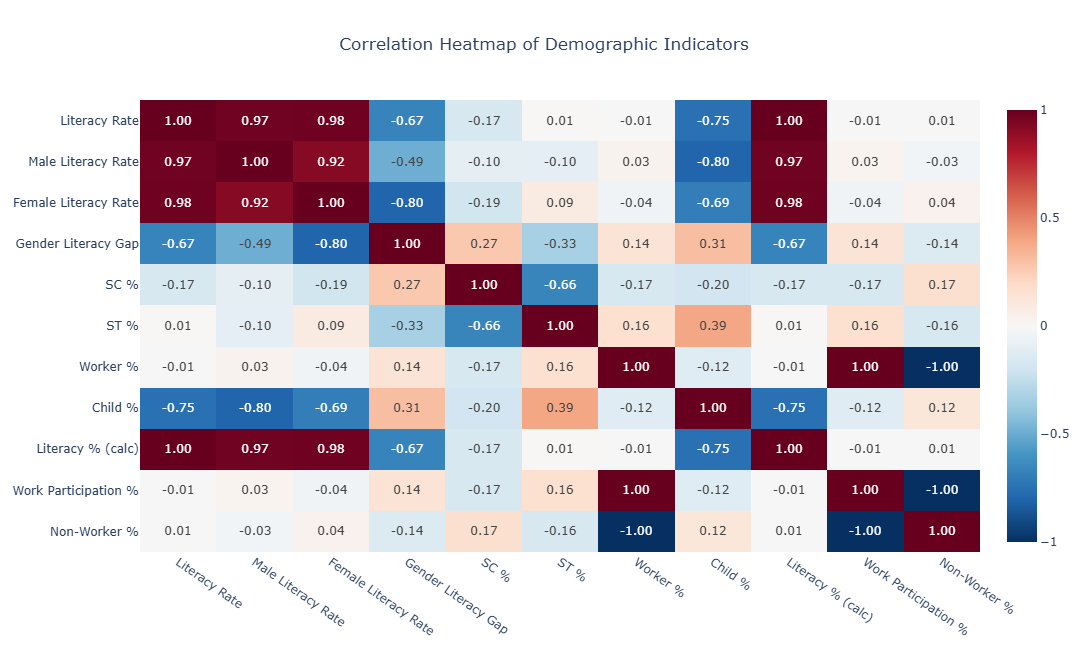

In [15]:
df = df_states.copy()
df['Child %'] = (
    df['Population in the age group 0-6 Person'] /
    df['Total Population Person']
) * 100
df['Literacy % (calc)'] = (
    df['Literates Population Person'] /
    df['Total Population Person']
) * 100
df['Work Participation %'] = (
    df['Total Worker Population Person'] /
    df['Total Population Person']
) * 100
df['Non-Worker %'] = (
    df['Non Working Population Person'] /
    df['Total Population Person']
) * 100
features = [
    'Literacy Rate',
    'Male Literacy Rate',
    'Female Literacy Rate',
    'Gender Literacy Gap',
    'SC %',
    'ST %',
    'Worker %',
    'Child %',
    'Literacy % (calc)',
    'Work Participation %',
    'Non-Worker %'
]

corr = df[features].corr()
fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    aspect='auto',
    title='Correlation Heatmap of Demographic Indicators'
)
fig.update_layout(
    height=650,
    width=900,
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.update_xaxes(tickangle=35)
chart10=fig
chart10

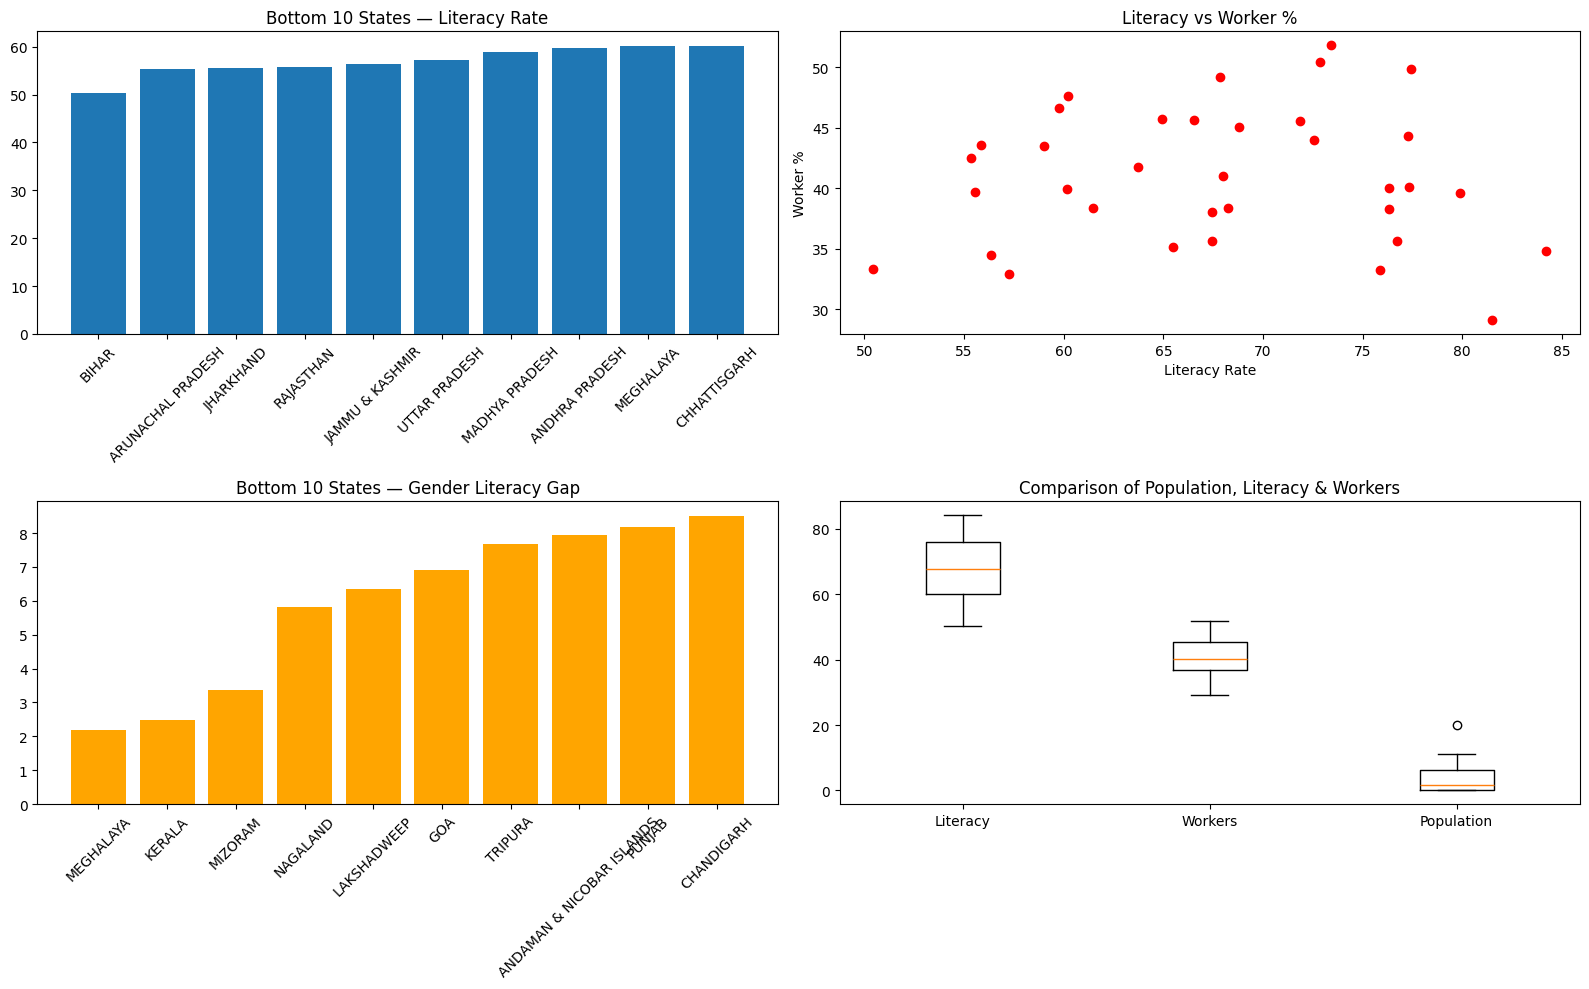

In [16]:
chart11, axs = plt.subplots(2, 2, figsize=(16, 10))

# 1️⃣ Literacy Rate (Bar)
df_lit = df_states.sort_values('Literacy Rate').head(10)
axs[0,0].bar(df_lit['Name'], df_lit['Literacy Rate'])
axs[0,0].set_title("Bottom 10 States — Literacy Rate")
axs[0,0].tick_params(axis='x', rotation=45)

# 2️⃣ Gender Gap (Bar)
df_gap = df_states.sort_values('Gender Literacy Gap').head(10)
axs[1,0].bar(df_gap['Name'], df_gap['Gender Literacy Gap'], color='orange')
axs[1,0].set_title("Bottom 10 States — Gender Literacy Gap")
axs[1,0].tick_params(axis='x', rotation=45)

# 5️⃣ Population (Box Plot)
axs[1,1].boxplot([
    df_states['Literacy Rate'],
    df_states['Worker %'],
    df_states['Total Population Person'] / 1e7
])
axs[1,1].set_title("Comparison of Population, Literacy & Workers")
axs[1,1].set_xticklabels(['Literacy', 'Workers','Population'])

# 6️⃣ Literacy vs Workers (Scatter)
axs[0,1].scatter(df_states['Literacy Rate'], df_states['Worker %'], color='red')
axs[0,1].set_title("Literacy vs Worker %")
axs[0,1].set_xlabel("Literacy Rate")
axs[0,1].set_ylabel("Worker %")

plt.tight_layout()
plt.show()

In [37]:
pn.extension('plotly', design='material', sizing_mode="stretch_width")

# -------- CSS & THEME (Premium Dark Mode with Glassmorphism) --------
CSS = """
.kpi-card {
    background: rgba(17, 45, 107, 0.4);
    backdrop-filter: blur(10px);
    -webkit-backdrop-filter: blur(10px);
    border: 1px solid rgba(255, 255, 255, 1);
    border-radius: 16px;
    padding: 20px;
    color: white;
    box-shadow: 0 4px 30px rgba(0, 0, 0, 1);
    transition: transform 0.3s ease, box-shadow 0.3s ease, background 0.3s ease;
    text-align: center;
}
.kpi-card:hover {
    transform: translateY(-5px) scale(1.02);
    box-shadow: 0 10px 40px rgba(59, 130, 246, 0.3);
    background: rgba(17, 45, 107, 0.6);
}
.kpi-title {
    font-size: 1.1em;
    font-weight: 500;
    color: #94A3B8;
    margin-bottom: 8px;
    letter-spacing: 1px;
    text-transform: uppercase;
}
.kpi-value {
    font-size: 2.2em;
    font-weight: 700;
    background: linear-gradient(135deg, #60A5FA, #A78BFA);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin: 0;
}
.dashboard-card {
    border-radius: 16px !important;
    overflow: hidden;
    box-shadow: 0 4px 20px rgba(0,0,0,0.2) !important;
    border: 1px solid rgba(255, 255, 255, 0.05) !important;
    background: linear-gradient(145deg, #112D6B 0%, #0A1F44 100%) !important;
}
"""
pn.extension(raw_css=[CSS])

BG = "#0B1121"        # Deep slate/navy dark
CARD = "#151F32"      # Slightly lighter for cards
ACCENT = "#3B82F6"    # vibrant blue
TEXT = "#E2E8F0"      # soft light text

topn_slider = pn.widgets.IntSlider(
    name='Top States to Display',
    start=5, end=35, step=5, value=15,
    bar_color=ACCENT, sizing_mode='stretch_width',
    styles={'color': TEXT}
)

metric_selector = pn.widgets.Select(
    options=['Total Population Person', 'Literacy Rate', 'Worker %', 'Child %'],
    value='Total Population Person', sizing_mode='stretch_width',
    styles={'color': TEXT}
)

@pn.depends(topn_slider, metric_selector)
def pop_chart(n, metric):
    df = df_states.sort_values('Total Population Person', ascending=False).head(n)
    fig = px.bar(
        df,
        x='Name',
        y='Total Population Person',
        color=metric,
        color_continuous_scale='Magma' if metric != 'Total Population Person' else 'Blues',
        title=f"Top {n} States by Population"
    )
    fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor=TEXT,
        font_color="#E2E8F0",
        margin=dict(l=20, r=20, t=40, b=20)
    )
    return fig

# # -------- KPI FUNCTION (HTML/CSS) --------
# def kpi_html(title, value):
#     return pn.pane.HTML(f"""
#     <div class="kpi-card">
#         <div class="kpi-title">{title}</div>
#         <div class="kpi-value">{value}</div>
#     </div>
#     """, sizing_mode='stretch_width')

# def format_num(n):
#     if n >= 1e9: return f"{n/1e9:.2f}B"
#     if n >= 1e6: return f"{n/1e6:1f}M"
#     return f"{n:,.0f}"

chart11_pane = pn.pane.Matplotlib(chart11, sizing_mode='scale_both', tight=True) if 'chart11' in globals() else pn.pane.Markdown("Chart 11 not available")

template = pn.template.FastListTemplate(
    title="✨ India Census Analytics Platform",
    theme="dark",
    
    sidebar=[
    pn.pane.Markdown("## 🎛️ Dashboard Controls", styles={'color': TEXT}),
    pn.pane.Markdown(
        "Customize how data is displayed across the dashboard. Adjust filters to explore different insights.",
        styles={'color': TEXT, 'font-size': '1em'}
    ),
    pn.layout.Divider(),
    pn.pane.Markdown("### 🔍 Data Filters", styles={'color': TEXT}),
    pn.pane.Markdown("**Select Top N States**", styles={'color': TEXT}),
    topn_slider,
    pn.Spacer(height=10),
    pn.pane.Markdown("**Color Metric**", styles={'color': TEXT}),
    metric_selector,
    pn.layout.Divider(),
    pn.pane.Markdown("### ⚡ Quick Insights", styles={'color': TEXT}),
    pn.pane.Markdown("""
- 📊 Higher population states tend to show diverse literacy patterns  
- 📚 Literacy rate varies significantly across regions  
- 👷 Workforce participation highlights economic activity  
- 👶 Child population % indicates future demographic trends  
    """, styles={'color': '#94A3B8', 'font-size': '1em'}),

    pn.layout.Divider(),

    pn.pane.Markdown("### 📘 Metric Guide", styles={'color': TEXT}),
    
    pn.pane.Markdown("""
- **Total Population:** Total number of individuals per state  
- **Literacy Rate:** Percentage of literate population  
- **Worker %:** Share of working population  
- **Child %:** Population aged below 6 years  
    """, styles={'color': '#94A3B8', 'font-size': '1em'}),

    pn.layout.Divider(),
        
    pn.pane.Markdown("### 🧭 How to Use", styles={'color': TEXT}),
    
    pn.pane.Markdown("""
1. Adjust the **Top States slider** to focus on key regions  
2. Change **Color Metric** to uncover hidden patterns  
3. Hover over charts for detailed values  
4. Compare multiple charts to identify correlations  
    """, styles={'color': '#94A3B8', 'font-size': '1em'}),

    pn.layout.Divider(),

    pn.pane.Markdown("### 📖 About Dashboard", styles={'color': TEXT}),
    
    pn.pane.Markdown("""
This platform visualizes Indian Census data to provide insights into:
- Population distribution  
- Education levels  
- Economic activity  
- Social diversity  

Designed with interactive analytics and modern UI for better decision-making.
    """, styles={'color': '#94A3B8', 'font-size': '1em'}),

    pn.layout.Divider(),

    pn.pane.Markdown(
        "✨ *Built with Panel & Plotly | Dark Analytics UI*",
        styles={'color': '#64748B', 'font-size': '1em', 'text-align': 'center'}
    )
],
    main=[
        pn.Column(
            pn.Row(
                kpi_html("Total Population", format_num(df_states['Total Population Person'].sum())),
                kpi_html("Total States/UTs", str(len(df_states))),
                kpi_html("Avg Literacy Rate", f"{df_states['Literacy Rate'].mean():.1f}%"),
                kpi_html("Total Districts", str(int(df_rhs['Number of Districts'].sum()))),
                sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),
            
            pn.Row(
                pn.Card(pop_chart, title="📊 Population Distribution", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=500, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),

            pn.Row(
                pn.Card(chart6, title="👥 Population Pyramid", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=500, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),

            pn.Row(
                pn.Card(chart4, title="📚 Literacy Rate by State", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=550, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),

            pn.Row(
                pn.Card(chart5, title="👷 Workforce Composition", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=550, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),
            
            pn.Row(
                pn.Card(chart8, title="🛡️ SC/ST Distribution", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=500, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),

             pn.Row(
                pn.Card(chart7, title="🕌 Religion Distribution", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=500, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),
            
            pn.Row(
                pn.Card(chart3, title="🎓 Literate vs Illiterate Gap", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=600, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),

            pn.Row(
                pn.Card(chart10, title="🔥 Correlation Matrix", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=600, sizing_mode='stretch_width'
            ),
            pn.Spacer(height=20),
            
            pn.Row(
                pn.Card(chart9, title="🏡 Villages vs Area by State", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=600, sizing_mode='stretch_width'
            ),
            pn.Row(
                pn.Card(chart11, title="📊 Comprehensive Comparisons", css_classes=['dashboard-card'], sizing_mode='stretch_both'),
                min_height=600, sizing_mode='stretch_width'
            )
        )
    ],
    accent_base_color=ACCENT,
    header_background=BG,
    background_color=BG,
    font="Inter, sans-serif"
)

template.show()

Launching server at http://localhost:63842
